MAE: 46.5143906790191
RMSE: 62.448192000959246
R2: 0.5153693215095645


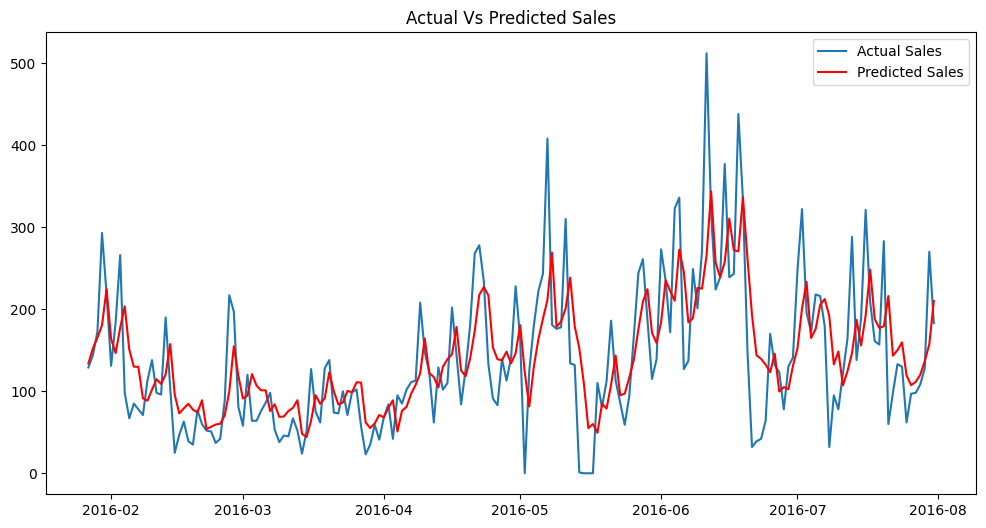

        date  predicted_sales
0 2016-07-31       281.074483
1 2016-08-01       123.794485
2 2016-08-02       129.071258
3 2016-08-03       134.348030
4 2016-08-04       139.624802


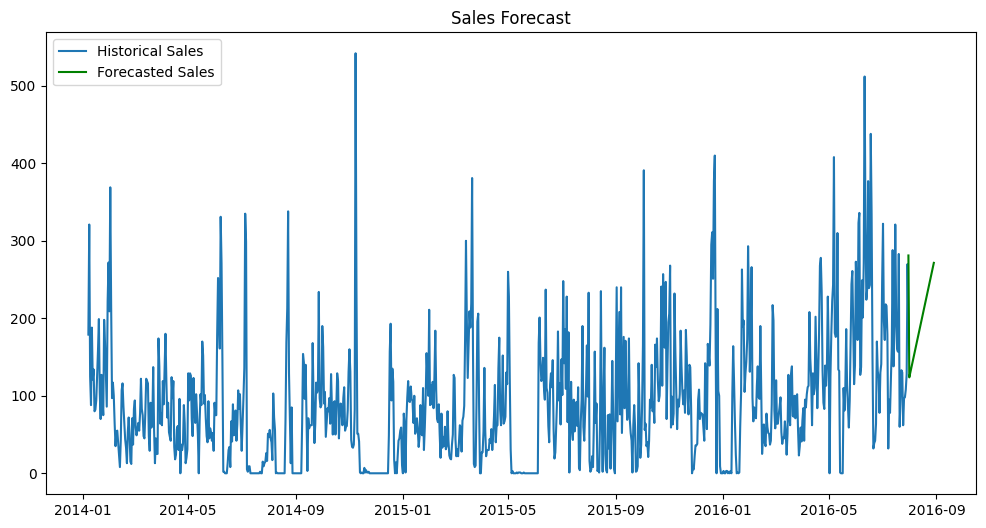

In [66]:
#dataset used here is retail sales forecasting for sales prediction with linear regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data=pd.read_csv(r"C:\Users\Jasmine Rahaman\Desktop\vscode\jasmine\DataScienceProjects\mock_kaggle.csv")
#print("Shape of the dataset\n")
#data.shape    #gives the number of rows and columns

#print("Converting the data into dataframe through pandas\n")
df=pd.DataFrame(data)
#df.head()

#df.info()   #describing the data

#df.isnull().sum()  #to get the count of any null values, 0 null values found in any column

#df['date']=pd.to_datetime(df['date'],dayfirst=True)      #change the date format to day-month-year
df['date']=pd.to_datetime(df['date'],format='%d-%m-%Y')
df['month']=df['date'].dt.month
df['day_of_week']=df['date'].dt.dayofweek
df['sales_lag1']=df['sale'].shift(1)
df['sales_ma7']=df['sale'].rolling(7).mean()
df=df.dropna()
df.head(10)

train_size=int(len(df)*0.8)
train=df.iloc[:train_size].copy()
test=df.iloc[train_size:].copy()

train.loc[:,'date_ordinal']=train['date'].map(lambda x: x.toordinal())
test.loc[:,'date_ordinal']=test['date'].map(lambda x: x.toordinal())

features=['date_ordinal','stock','price','month','day_of_week','sales_ma7','sales_lag1']
X_train=train[features]
y_train=train['sale']
X_test=test[features]
y_test=test['sale']

model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print("MAE:",mean_absolute_error(y_test, y_pred))
mse=mean_squared_error(y_test, y_pred)
rmse=mse**0.5
print("RMSE:",rmse)
print("R2:",r2_score(y_test,y_pred))

#actual vs predicted graph
plt.figure(figsize=(12,6))
plt.plot(test['date'],y_test,label='Actual Sales')
plt.plot(test['date'],y_pred,label='Predicted Sales',color='red')
plt.legend()
plt.title("Actual Vs Predicted Sales")
plt.show()

# Generate future dates (next 30 days)
future_dates = pd.date_range(df['date'].max(), periods=30, freq='D')
future_ordinals = future_dates.map(lambda x: x.toordinal()).values

# Assume average stock/price for forecast
future_stock = np.full((30,), df['stock'].mean())
future_price = np.full((30,), df['price'].mean())
future_month = future_dates.month
future_dayofmonth = future_dates.day
future_ma7 = np.full((30,), df['sales_ma7'].mean())
future_lag1 = np.full((30,), df['sale'].iloc[-1])  # last known sale

# Build future feature set
future_X = pd.DataFrame({
    'date_ordinal': future_ordinals,
    'stock': future_stock,
    'price': future_price,
    'month': future_month,
    'day_of_week': future_dayofmonth,
    'sales_ma7': future_ma7,
    'sales_lag1': future_lag1
})

# Predict future sales
future_preds = model.predict(future_X)
forecast = pd.DataFrame({"date": future_dates, "predicted_sales": future_preds})

print(forecast.head())

# Plot forecast
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['sale'], label="Historical Sales")
plt.plot(forecast['date'], forecast['predicted_sales'], label="Forecasted Sales", color='green')
plt.legend()
plt.title("Sales Forecast")
plt.show()